Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Import Data

In [2]:
df = pd.read_csv('cars-data.csv')
df.head()

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,B
1,mazda,2,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,B
2,mazda,2,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,B
3,mazda,2,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,B
4,mazda,2,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,B


Exploratory Data Analysis

In [3]:
df.shape
df.dtypes

make                    object
model                   object
priceUSD                 int64
year                     int64
condition               object
mileage(kilometers)    float64
fuel_type               object
volume(cm3)            float64
color                   object
transmission            object
drive_unit              object
segment                 object
dtype: object

In [4]:
df.drop(columns= ['model', 'segment'], inplace=True)

In [5]:
df.nunique()

make                     96
priceUSD               2970
year                     78
condition                 3
mileage(kilometers)    8400
fuel_type                 3
volume(cm3)             458
color                    13
transmission              2
drive_unit                4
dtype: int64

In [6]:
df['make'].unique()

array(['mazda', 'mg', 'renault', 'gaz', 'aro', 'rover', 'uaz',
       'alfa-romeo', 'audi', 'oldsmobile', 'saab', 'peugeot', 'chrysler',
       'wartburg', 'moskvich', 'volvo', 'fiat', 'roewe', 'porsche', 'zaz',
       'luaz', 'dacia', 'lada-vaz', 'izh', 'raf', 'bogdan', 'bmw',
       'nissan', 'mercedes-benz', 'mitsubishi', 'toyota', 'chery', 'gmc',
       'hyundai', 'honda', 'ssangyong', 'suzuki', 'opel', 'seat',
       'volkswagen', 'daihatsu', 'chevrolet', 'geely', 'saturn', 'kia',
       'lincoln', 'eksklyuziv', 'citroen', 'dong-feng', 'pontiac', 'ford',
       'subaru', 'bentley', 'faw', 'cadillac', 'lifan', 'plymouth',
       'hafei', 'shanghai-maple', 'mini', 'jeep', 'skoda', 'mercury',
       'changan', 'lexus', 'isuzu', 'aston-martin', 'lancia',
       'great-wall', 'land-rover', 'jaguar', 'buick', 'daewoo', 'vortex',
       'infiniti', 'byd', 'smart', 'maserati', 'haval', 'acura', 'scion',
       'tata', 'datsun', 'tesla', 'mclaren', 'ravon', 'trabant', 'proton',
       'fso

In [7]:
def car_make(make):
    if make in ['mazda', 'mg', 'rover','alfa-romeo', 'audi', 'peugeot', 'chrysler', 'bmw', 'aston-martin','jaguar', 'land-rover']:
        return 'Luxury European'
    elif make in ['renault','dacia', 'citroen', 'volvo', 'fiat', 'opel', 'seat', 'volkswagen', 'citroen', 'skoda', 'mini', 'smart' ]:
        return 'Mainstream European'
    elif make in ['gaz', 'aro', 'lada-vaz', 'izh', 'raf', 'bogdan', 'moskvich', 'uaz', 'luaz', 'wartburg', 'trabant', 'proton', 'fso', 'jac', 'iran-khodro', 'zotye', 'tagaz', 'saipa', 'brilliance']:
        return 'Russian/Eastern European'
    elif make in ['toyota', 'nissan','asia', 'mitsubishi', 'chery', 'hyundai', 'honda', 'ssangyong', 'suzuki', 'daihatsu', 'kia', 'changan', 'lexus', 'isuzu', 'great-wall', 'daewoo', 'vortex', 'infiniti', 'byd', 'geely', 'haval', 'acura', 'scion', 'tata', 'datsun', 'ravon', 'proton', 'jac']:
        return 'Asian'
    elif make in ['oldsmobile', 'gmc', 'chrysler', 'plymouth', 'ford', 'cadillac', 'jeep', 'mercury', 'lincoln', 'buick', 'saturn', 'pontiac', 'chevrolet']:
        return 'American'
    elif make in ['porsche','bentley', 'maserati', 'tesla', 'mclaren']:
        return 'Specialty'
    else:
        return 'Other'
    
df['make_category'] = df['make'].apply(car_make)

In [8]:
df.describe()

,priceUSD,year,mileage(kilometers),volume(cm3)
count,56244.000000,56244.000000,5.624400e+04,56197.000000
mean,7415.456440,2003.454840,2.443956e+05,2104.860615
std,8316.959261,8.144247,3.210307e+05,959.201633
min,48.000000,1910.000000,0.000000e+00,500.000000
25%,2350.000000,1998.000000,1.370000e+05,1600.000000
50%,5350.000000,2004.000000,2.285000e+05,1996.000000
75%,9807.500000,2010.000000,3.100000e+05,2300.000000
max,235235.000000,2019.000000,9.999999e+06,20000.000000


In [9]:
df.head()

,make,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,make_category
0,mazda,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,Luxury European
1,mazda,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,Luxury European
2,mazda,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,Luxury European
3,mazda,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,Luxury European
4,mazda,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,Luxury European


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Luxury European'),
  Text(1, 0, 'Mainstream European'),
  Text(2, 0, 'Russian/Eastern European'),
  Text(3, 0, 'American'),
  Text(4, 0, 'Other'),
  Text(5, 0, 'Specialty'),
  Text(6, 0, 'Asian')])

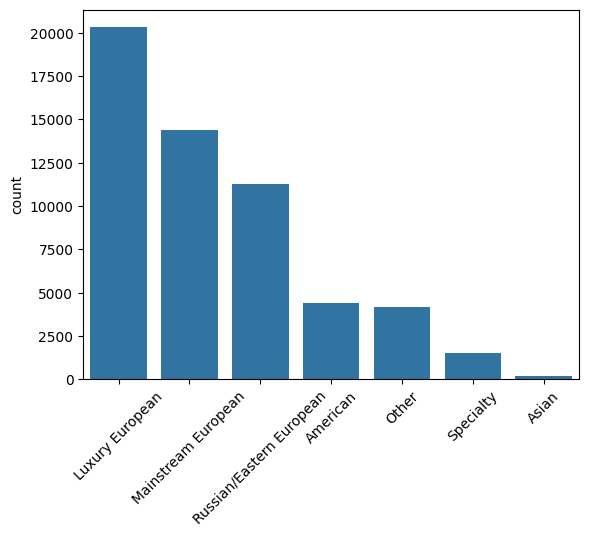

In [10]:
sns.barplot(x=df['make_category'].unique(), y=df['make_category'].value_counts())
plt.xticks(rotation=45)

Categorical Variable Distribution

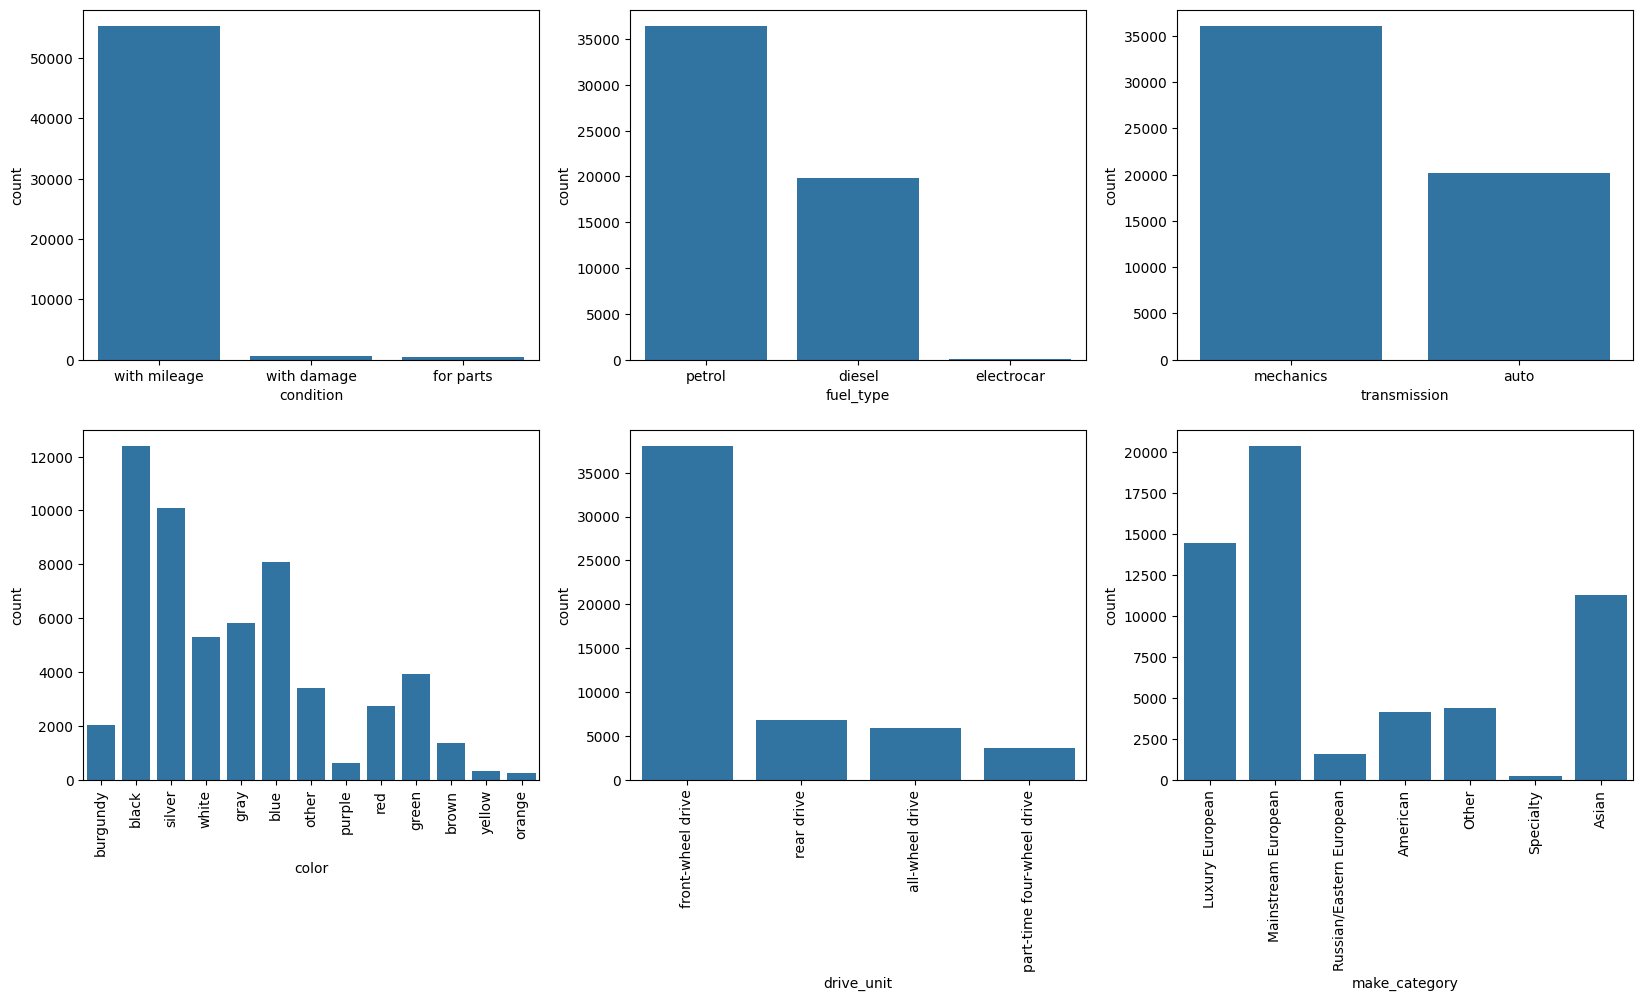

In [11]:
fig, ax = plt.subplots(2,3,figsize=(20, 10))
sns.countplot(x=df['condition'], ax=ax[0,0])
sns.countplot(x=df['fuel_type'], ax=ax[0,1])
sns.countplot(x=df['transmission'], ax=ax[0,2])
sns.countplot(x=df['color'], ax=ax[1,0])
ax[1,0].tick_params(axis='x', rotation=90)
sns.countplot(x=df['drive_unit'], ax=ax[1,1])
ax[1,1].tick_params(axis='x', rotation=90)
sns.countplot(x=df['make_category'], ax=ax[1,2])
ax[1,2].tick_params(axis='x', rotation=90)

Continuous Variable Distribution

<Axes: xlabel='volume(cm3)', ylabel='Count'>

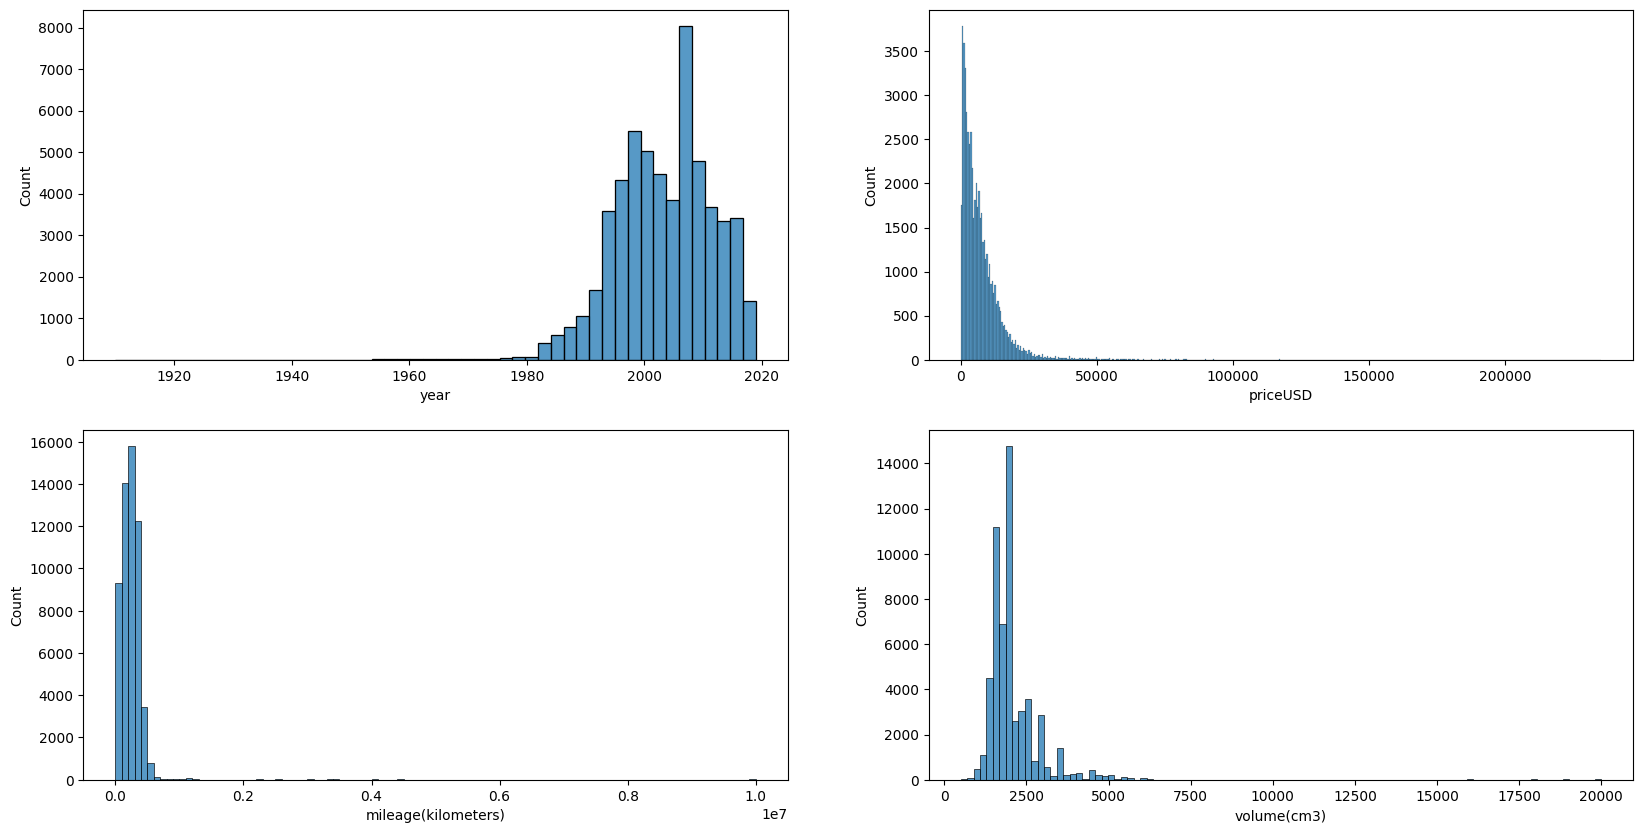

In [12]:
fig, ax = plt.subplots(2,2,figsize=(20,10))
sns.histplot (df['year'], ax=ax[0,0], bins = 50)
sns.histplot(df['priceUSD'], ax=ax[0,1])
sns.histplot(df['mileage(kilometers)'], ax=ax[1,0], bins = 100)
sns.histplot(df['volume(cm3)'], ax=ax[1,1], bins = 100)

In [13]:
df = df[df['year'] > 1980]

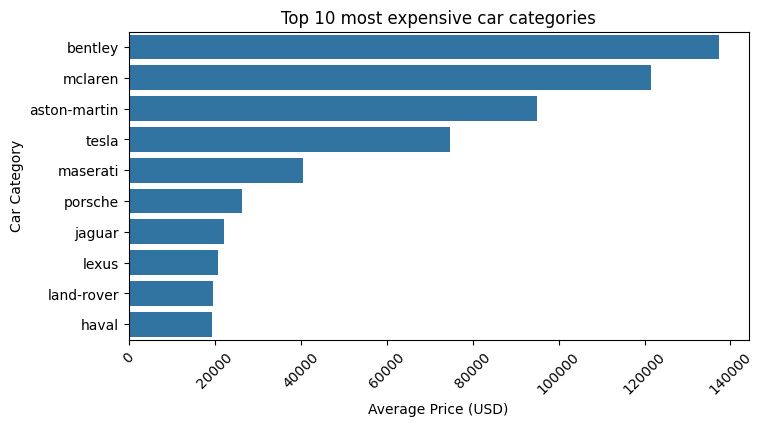

In [14]:
demodf = df.groupby('make')['priceUSD'].mean().reset_index()
demodf = demodf.sort_values(by='priceUSD', ascending=False).head(10)

plt.figure(figsize=(8,4))
sns.barplot(y='make', x='priceUSD', data=demodf)
plt.xticks(rotation=45)
plt.title('Top 10 most expensive car categories')
plt.ylabel('Car Category')
plt.xlabel('Average Price (USD)')
plt.show()

Text(0.5, 1.0, 'Price of cars based on drive unit')

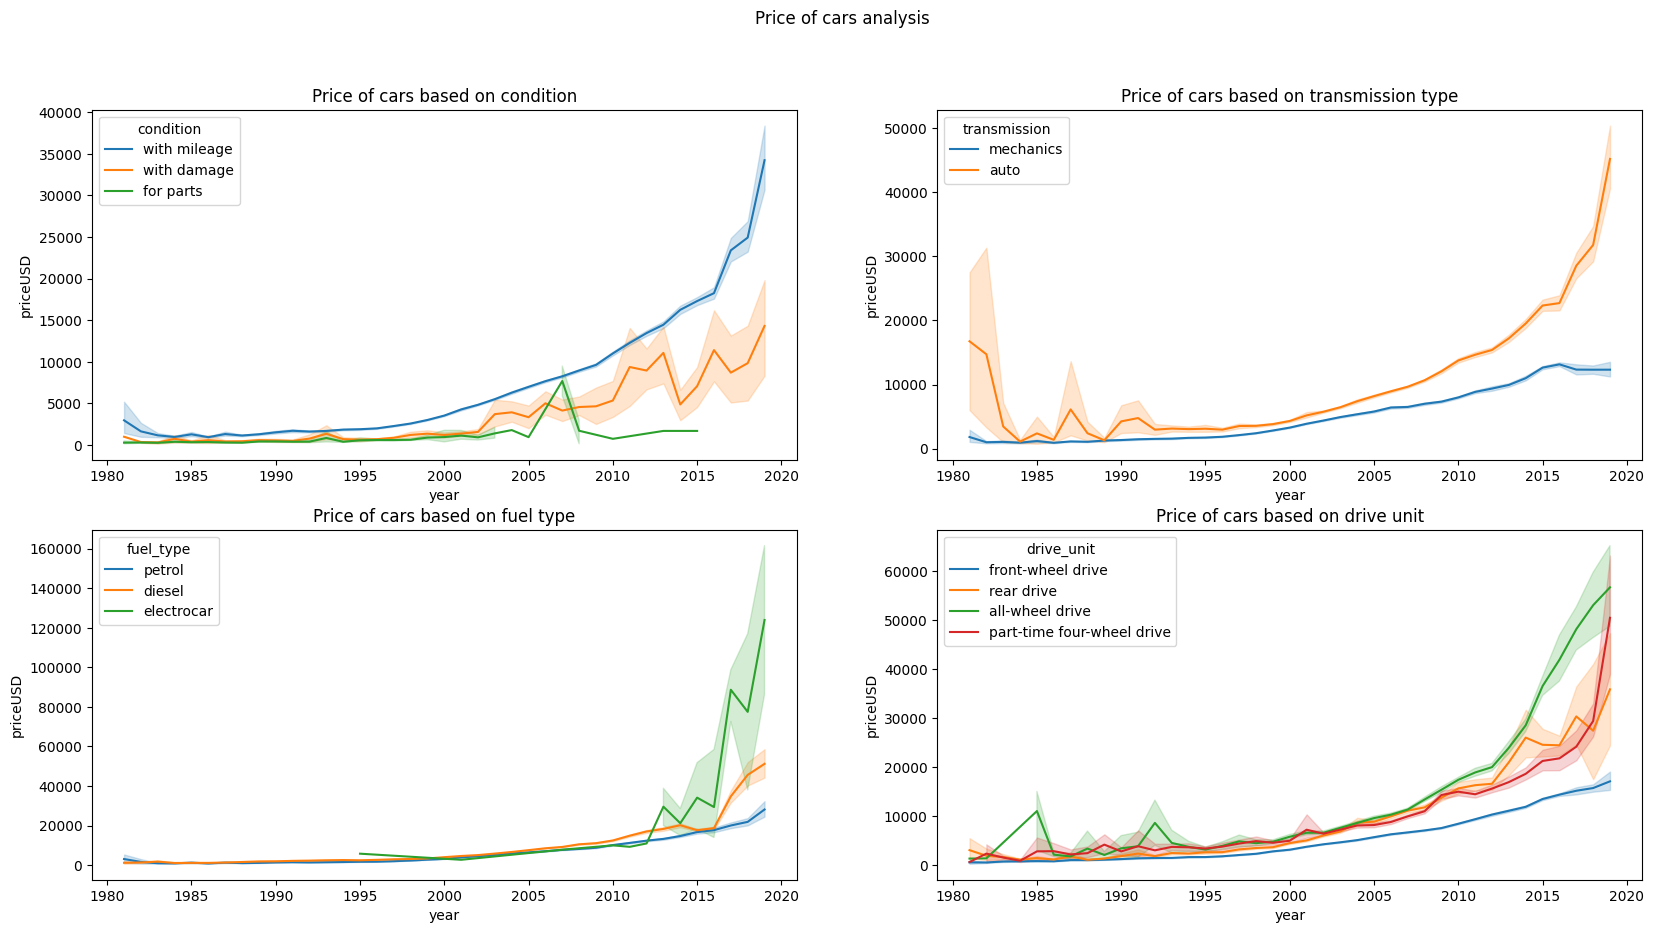

In [15]:
fig, ax = plt.subplots(2,2,figsize=(20,10))
fig.suptitle('Price of cars analysis')
sns.lineplot(x=df['year'], y=df['priceUSD'], hue = df['condition'], ax=ax[0,0])
ax[0,0].set_title('Price of cars based on condition')
sns.lineplot(x=df['year'], y=df['priceUSD'], hue = df['transmission'], ax=ax[0,1])
ax[0,1].set_title('Price of cars based on transmission type')
sns.lineplot(x=df['year'], y=df['priceUSD'], hue = df['fuel_type'], ax=ax[1,0])
ax[1,0].set_title('Price of cars based on fuel type')
sns.lineplot(x=df['year'], y=df['priceUSD'], hue = df['drive_unit'], ax=ax[1,1])
ax[1,1].set_title('Price of cars based on drive unit')

Text(0.5, 1.0, 'Price of cars based on make category')

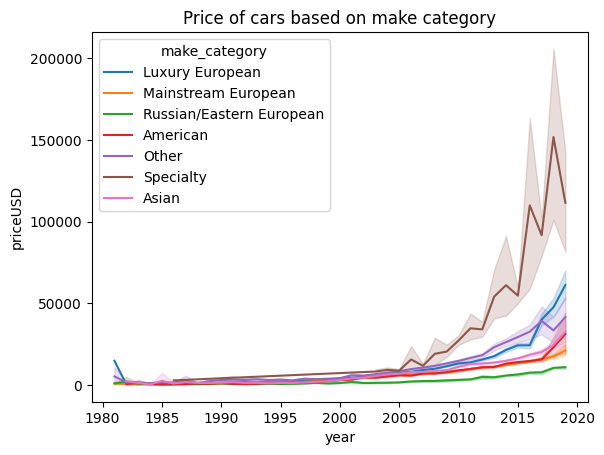

In [16]:
sns.lineplot(x=df['year'], y=df['priceUSD'], hue = df['make_category'])
plt.title('Price of cars based on make category')

In [17]:
df.isnull().sum()

make                      0
priceUSD                  0
year                      0
condition                 0
mileage(kilometers)       0
fuel_type                 0
volume(cm3)              47
color                     0
transmission              0
drive_unit             1874
make_category             0
dtype: int64

In [18]:
df.dropna(inplace=True)

df.drop(columns=['make'], inplace=True)

Preprocessing

In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cols = ['condition', 'fuel_type', 'transmission', 'color', 'drive_unit', 'make_category']

for col in cols:
    le.fit(df[col])
    df[col] = le.transform(df[col])
    print(f'{col} : {df[col].unique()}')

condition : [2 1 0]
fuel_type : [1 0]
transmission : [1 0]
color : [ 3  0 10 11  4  1  7  8  9  5  2 12  6]
drive_unit : [1 3 0 2]
make_category : [2 3 5 0 4 6 1]


Text(0.5, 1.0, 'Correlation Heatmap')

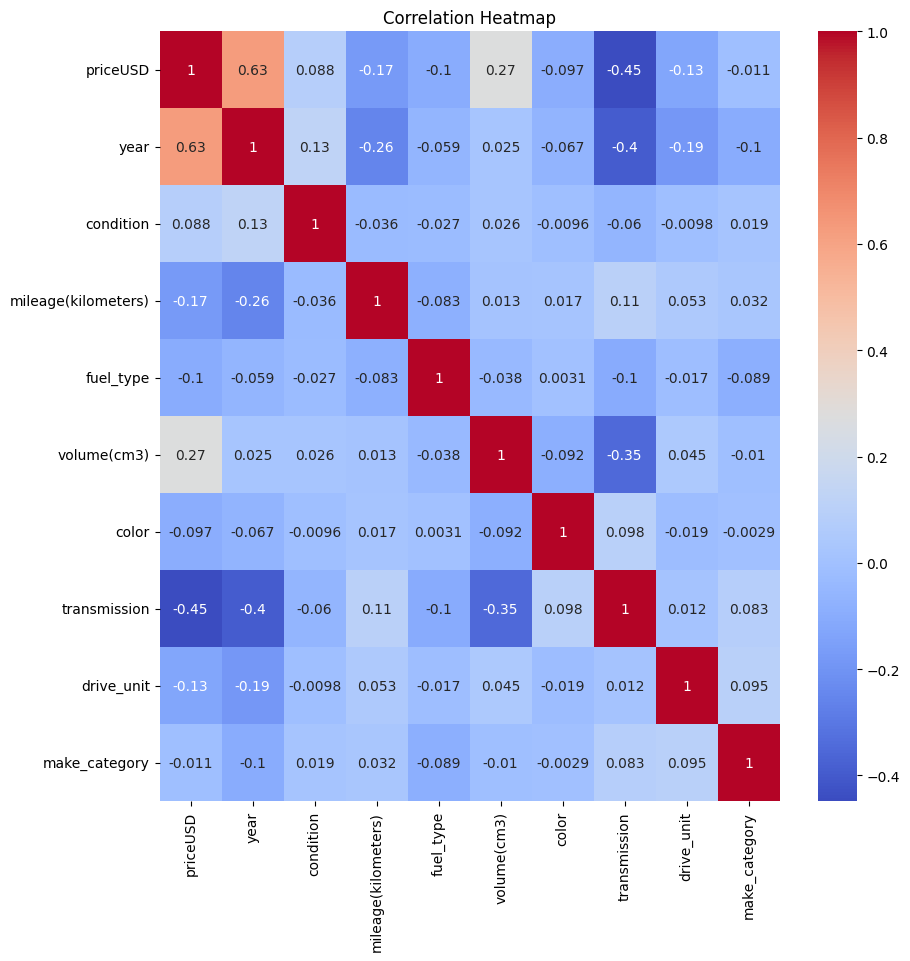

In [22]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

In [23]:
from scipy import stats
z = np.abs(stats.zscore(df))

threshold = 3

cols = ['year', 'mileage(kilometers)', 'volume(cm3)']\

df = df[(z < threshold).all(axis=1)]

Train Model

In [26]:
from sklearn.model_selection import train_test_split, GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['priceUSD']), df['priceUSD'], test_size=0.2, random_state=42)

In [51]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor()

params = {
    'max_depth': [2,4,6,8,10],
    'min_samples_split': [2,4,6,8,10],
    'min_samples_leaf': [1,2,3,4,5],
    'max_features': [None, 'sqrt', 'log2'],
    'random_state': [0,42]
}

grid = GridSearchCV(dtr, param_grid=params, cv=5, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)
print(grid.best_params_)


Fitting 5 folds for each of 750 candidates, totalling 3750 fits
{'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'random_state': 0}


In [52]:
dtr = DecisionTreeRegressor(max_depth=10, max_features=None, min_samples_leaf=4, min_samples_split=10, random_state=0)
dtr.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_lea

In [53]:
dtr.score(X_train, y_train)

0.8940167299090456

In [54]:
y_pred = dtr.predict(X_test)

Evaluate Model

In [55]:

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
print('R2 Score: ', r2_score(y_test, y_pred))
print('Mean Squared Error: ', mean_squared_error(y_test, y_pred))
print('Mean Absolute Error: ', mean_absolute_error(y_test, y_pred))
print('Root Mean Squared Error: ', np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score:  0.8684290105827169
Mean Squared Error:  4210638.69756809
Mean Absolute Error:  1331.1458439211185
Root Mean Squared Error:  2051.984088039693


In [59]:
feature_importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': dtr.feature_importances_})
feature_importances.sort_values(by='Importance', ascending=False, inplace=True)
feature_importances

,Feature,Importance
0,year,0.737124
4,volume(cm3),0.201699
3,fuel_type,0.018406
8,make_category,0.014199
7,drive_unit,0.011302
6,transmission,0.010254
2,mileage(kilometers),0.005746
5,color,0.001270
1,condition,0.000000
